# Los bosques vírgenes de Suecia almacenan ~72% más carbono que los manejados

324 parcelas de bosque primario boreal comparadas con 28,580 de bosque secundario. La diferencia está en el suelo — el mayor almacén de carbono, y el que más se subestimaba.

---

**Paper:** Sabatini, Anderegg, Angelstam et al. (2026) — *Science*
**DOI:** [10.1126/science.adz8554](https://doi.org/10.1126/science.adz8554)
**Video:** [Ver en YouTube](https://youtube.com/watch?v=ZspFSOCVxio)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-28-carbono-bosques-virgenes/notebook.ipynb)

## El contexto

Los bosques boreales son un almacén enorme de carbono. Pero Suecia ha convertido la mayoría de sus bosques en bosques secundarios manejados (plantaciones, tala selectiva, rotación). ¿Cuánto carbono se pierde con eso?

Este equipo hizo lo que nadie había hecho a esta escala: inventariar 324 parcelas de bosque primario (virgen, sin intervención humana) y compararlas con 28,580 parcelas de bosque secundario del inventario forestal nacional sueco (NFI). Midieron carbono en tres partes del ecosistema: árboles vivos, madera muerta y suelo.

Los datos vienen de mediciones de campo directas — diámetros de árboles, muestras de suelo a 60 cm de profundidad, y madera muerta en descomposición.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PROFUNDIDAD_SUELO = 60          # cm — profundidad de muestreo SOC
FUENTE = 'Fuente: Sabatini et al. (2026), Science | Datos: Zenodo 10.5281/zenodo.17743108'
COLOR_PRIMARIO = '#059669'      # Emerald — bosque primario
COLOR_SECUNDARIO = '#D97706'    # Amber — bosque secundario
COLOR_DATOS = '#2563EB'         # Azul CaM
COLOR_ALERTA = '#DC2626'        # Rojo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Descargar datos
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
for archivo in ['vegetacion_pareado.csv', 'suelo_pareado.csv']:
    if not os.path.exists(f'datos/{archivo}'):
        urllib.request.urlretrieve(f'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-03-28-carbono-bosques-virgenes/datos/{archivo}', f'datos/{archivo}')

# Cargar
df_veg = pd.read_csv('datos/vegetacion_pareado.csv')
df_soc = pd.read_csv('datos/suelo_pareado.csv')

print(f"Vegetación: {len(df_veg)} parcelas ({(df_veg.es_primario==1).sum()} primarias + {(df_veg.es_primario==0).sum()} secundarias)")
print(f"Suelo: {len(df_soc)} parcelas ({(df_soc.es_primario==1).sum()} primarias + {(df_soc.es_primario==0).sum()} secundarias)")

Vegetación: 28904 parcelas (324 primarias + 28580 secundarias)
Suelo: 1115 parcelas (212 primarias + 903 secundarias)


## Aquí está la diferencia.

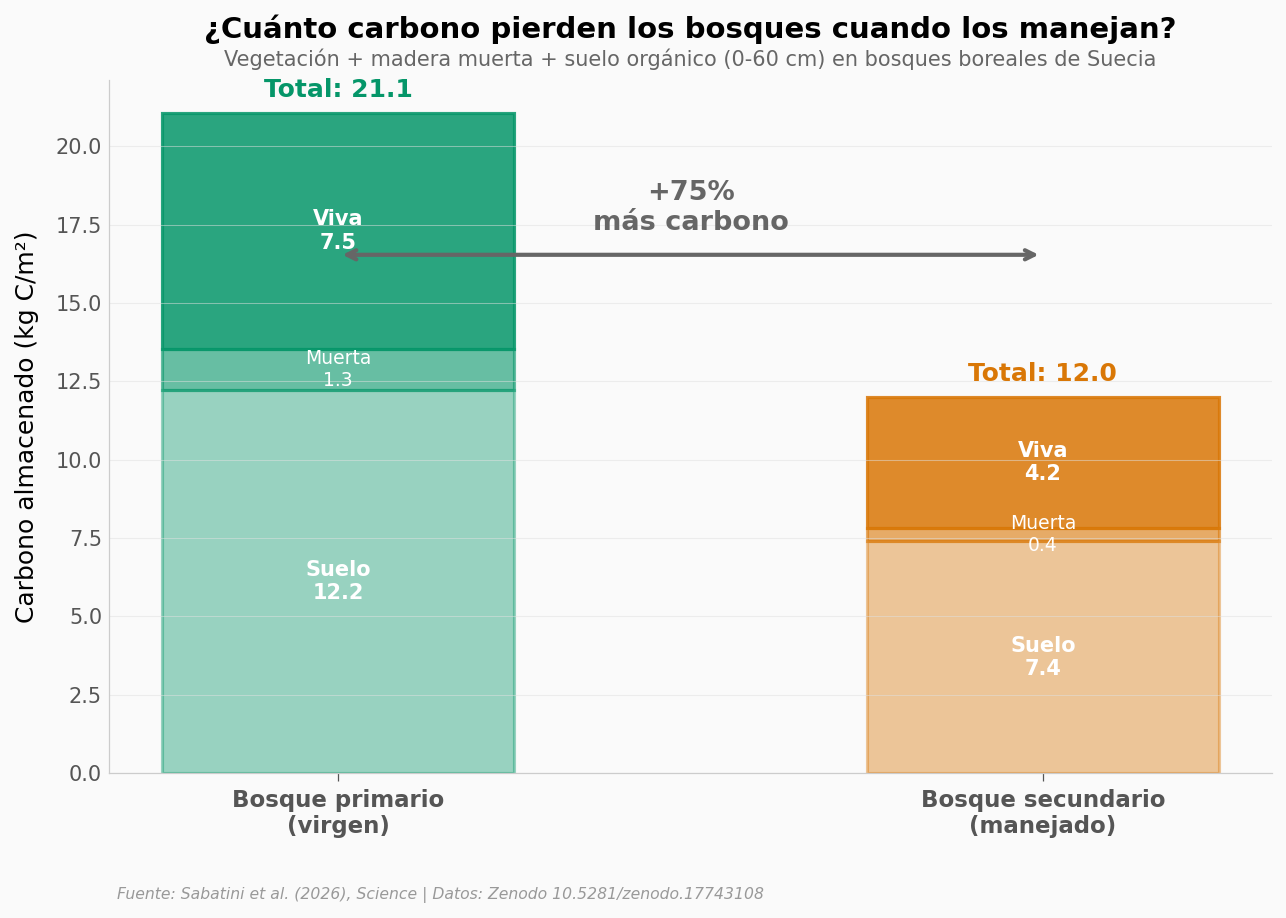

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

# Compute means by forest type
prim_live = df_veg[df_veg.es_primario == 1]['biomasa_viva_kgCm2'].mean()
sec_live = df_veg[df_veg.es_primario == 0]['biomasa_viva_kgCm2'].mean()
prim_dead = df_veg[df_veg.es_primario == 1]['madera_muerta_kgCm2'].mean()
sec_dead = df_veg[df_veg.es_primario == 0]['madera_muerta_kgCm2'].mean()
prim_soc = df_soc[df_soc.es_primario == 1]['soc_60cm_kgCm2'].mean()
sec_soc = df_soc[df_soc.es_primario == 0]['soc_60cm_kgCm2'].mean()

x = [0, 1]
labels = ['Bosque primario\n(virgen)', 'Bosque secundario\n(manejado)']
colors_stack = [COLOR_PRIMARIO, COLOR_SECUNDARIO]

# Stacked bars
for i, (live, dead, soc, color) in enumerate([
    (prim_live, prim_dead, prim_soc, COLOR_PRIMARIO),
    (sec_live, sec_dead, sec_soc, COLOR_SECUNDARIO)
]):
    ax.bar(i, soc, width=0.5, color=color, alpha=0.4, edgecolor=color, linewidth=1.5)
    ax.bar(i, dead, width=0.5, bottom=soc, color=color, alpha=0.6, edgecolor=color, linewidth=1.5)
    ax.bar(i, live, width=0.5, bottom=soc+dead, color=color, alpha=0.85, edgecolor=color, linewidth=1.5)
    
    # Labels inside bars
    total = live + dead + soc
    ax.text(i, soc/2, f'Suelo\n{soc:.1f}', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    ax.text(i, soc + dead/2, f'Muerta\n{dead:.1f}', ha='center', va='center', fontsize=9, color='white')
    ax.text(i, soc + dead + live/2, f'Viva\n{live:.1f}', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    ax.text(i, total + 0.5, f'Total: {total:.1f}', ha='center', fontsize=12, fontweight='bold', color=color)

# Difference arrow
prim_total = prim_live + prim_dead + prim_soc
sec_total = sec_live + sec_dead + sec_soc
mid_y = (prim_total + sec_total) / 2
ax.annotate('', xy=(1, mid_y), xytext=(0, mid_y),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=2))
diff_pct = ((prim_total - sec_total) / sec_total) * 100
ax.text(0.5, mid_y + 0.8, f'+{diff_pct:.0f}%\nmás carbono',
        ha='center', fontsize=13, fontweight='bold', color='#666666')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylabel('Carbono almacenado (kg C/m²)', fontsize=12)
ax.set_title('¿Cuánto carbono pierden los bosques cuando los manejan?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Vegetación + madera muerta + suelo orgánico (0-60 cm) en bosques boreales de Suecia',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/carbono_primario_vs_secundario.png', dpi=200, bbox_inches='tight')
plt.show()

Cada barra tiene tres capas: suelo (la base, más oscura), madera muerta (medio), y árboles vivos (arriba).

El bosque primario almacena **21.1 kg C/m²** en total, vs **12.0 kg C/m²** del secundario — un **75% más**. El paper reporta ~72% usando métodos pareados; nuestro cálculo directo da 75%, ligeramente por encima del rango pareado del paper (70-74%). La diferencia viene de usar medias directas en vez de pares controlados por humedad del suelo.

El dato más sorprendente: **el suelo es el mayor almacén** en ambos tipos de bosque (12.2 vs 7.4 kg C/m²), y también es donde está la mayor diferencia absoluta. La gestión forestal no solo reduce los árboles — los datos apuntan a que también transforma el suelo.

## La distribución completa

Los promedios cuentan parte de la historia. Veamos cómo se distribuyen las 29,000+ parcelas.

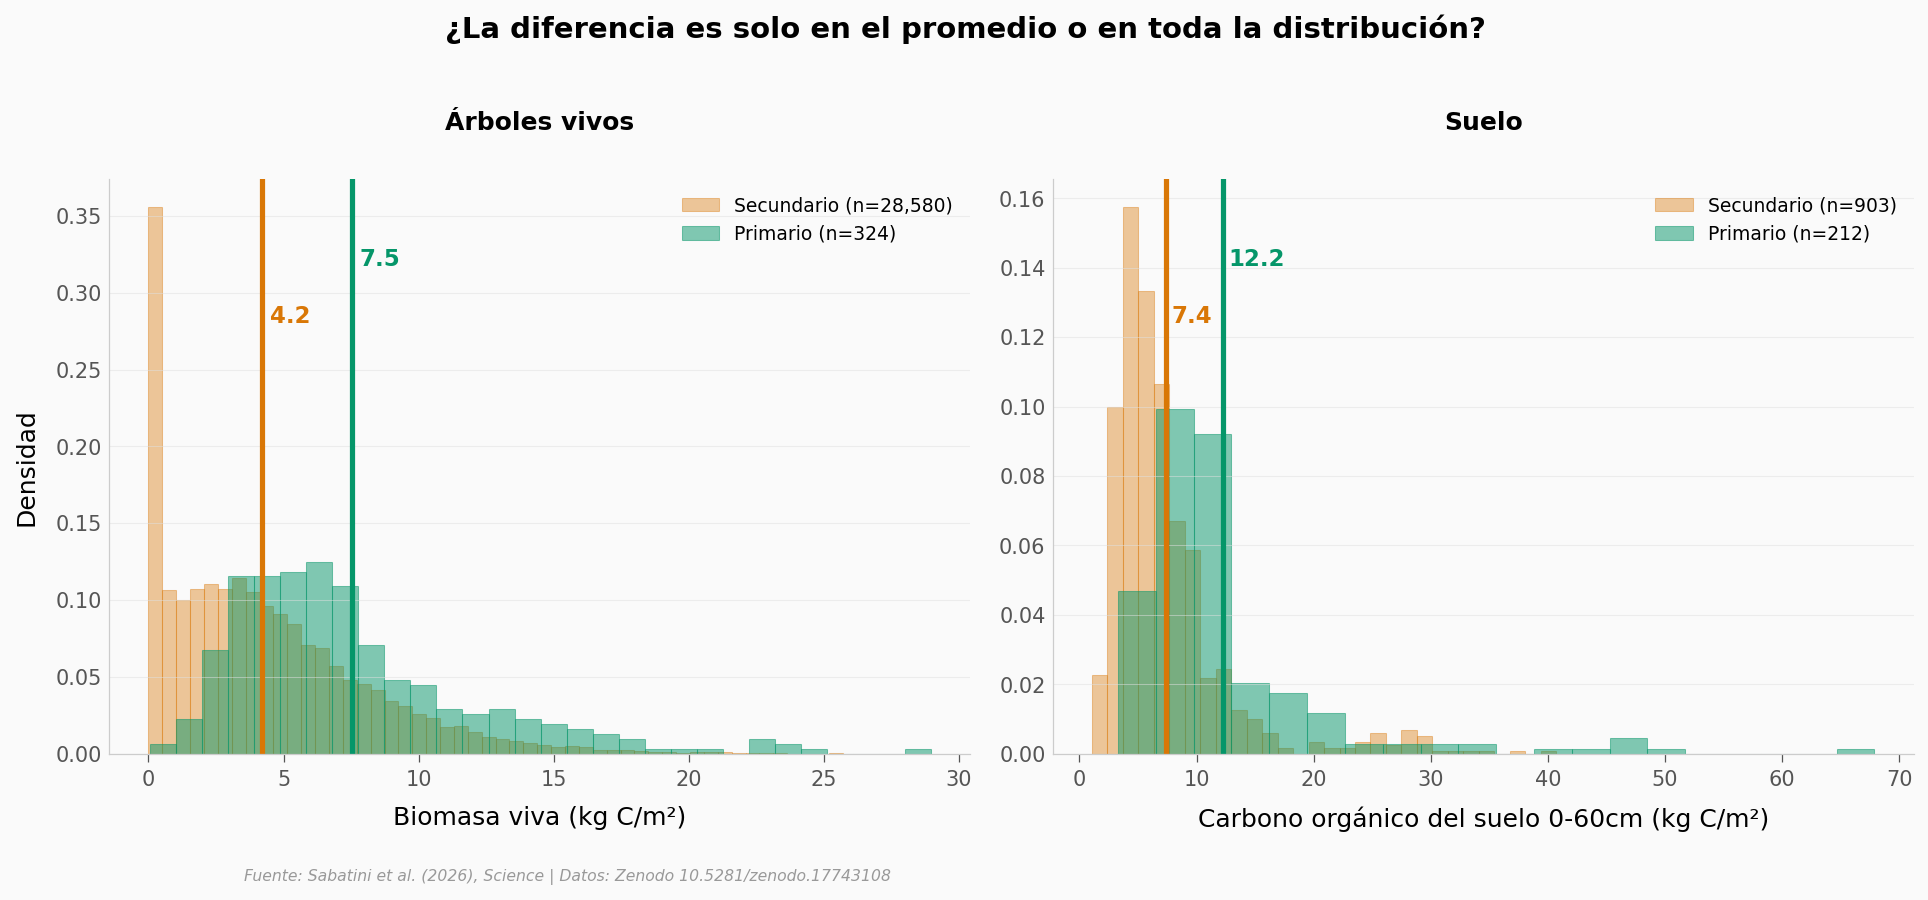

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: Live biomass
ax = axes[0]
prim = df_veg[df_veg.es_primario == 1]['biomasa_viva_kgCm2']
sec = df_veg[df_veg.es_primario == 0]['biomasa_viva_kgCm2']

ax.hist(sec, bins=50, color=COLOR_SECUNDARIO, alpha=0.4, edgecolor=COLOR_SECUNDARIO,
        linewidth=0.5, density=True, label=f'Secundario (n={len(sec):,})')
ax.hist(prim, bins=30, color=COLOR_PRIMARIO, alpha=0.5, edgecolor=COLOR_PRIMARIO,
        linewidth=0.5, density=True, label=f'Primario (n={len(prim)})')

ax.axvline(prim.mean(), color=COLOR_PRIMARIO, linewidth=2.5, linestyle='-')
ax.axvline(sec.mean(), color=COLOR_SECUNDARIO, linewidth=2.5, linestyle='-')

ax.text(prim.mean() + 0.3, ax.get_ylim()[1]*0.85, f'{prim.mean():.1f}',
        fontsize=11, fontweight='bold', color=COLOR_PRIMARIO)
ax.text(sec.mean() + 0.3, ax.get_ylim()[1]*0.75, f'{sec.mean():.1f}',
        fontsize=11, fontweight='bold', color=COLOR_SECUNDARIO)

ax.set_xlabel('Biomasa viva (kg C/m²)')
ax.set_ylabel('Densidad')
ax.set_title('Árboles vivos', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

# Right: SOC
ax = axes[1]
prim_s = df_soc[df_soc.es_primario == 1]['soc_60cm_kgCm2'].dropna()
sec_s = df_soc[df_soc.es_primario == 0]['soc_60cm_kgCm2'].dropna()

ax.hist(sec_s, bins=30, color=COLOR_SECUNDARIO, alpha=0.4, edgecolor=COLOR_SECUNDARIO,
        linewidth=0.5, density=True, label=f'Secundario (n={len(sec_s)})')
ax.hist(prim_s, bins=20, color=COLOR_PRIMARIO, alpha=0.5, edgecolor=COLOR_PRIMARIO,
        linewidth=0.5, density=True, label=f'Primario (n={len(prim_s)})')

ax.axvline(prim_s.mean(), color=COLOR_PRIMARIO, linewidth=2.5, linestyle='-')
ax.axvline(sec_s.mean(), color=COLOR_SECUNDARIO, linewidth=2.5, linestyle='-')

ax.text(prim_s.mean() + 0.5, ax.get_ylim()[1]*0.85, f'{prim_s.mean():.1f}',
        fontsize=11, fontweight='bold', color=COLOR_PRIMARIO)
ax.text(sec_s.mean() + 0.5, ax.get_ylim()[1]*0.75, f'{sec_s.mean():.1f}',
        fontsize=11, fontweight='bold', color=COLOR_SECUNDARIO)

ax.set_xlabel('Carbono orgánico del suelo 0-60cm (kg C/m²)')
ax.set_title('Suelo', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

plt.suptitle('¿La diferencia es solo en el promedio o en toda la distribución?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribuciones_carbono.png', dpi=200, bbox_inches='tight')
plt.show()

La diferencia no es solo en el promedio — toda la distribución del bosque primario está desplazada a la derecha. Hay parcelas secundarias con alto carbono y parcelas primarias con poco, pero la tendencia es clara.

## ¿Y por clase de humedad del suelo?

El análisis pareado del paper compara bosques primarios con sus vecinos secundarios controlando por humedad del suelo. Veamos si la diferencia se mantiene en todas las clases.

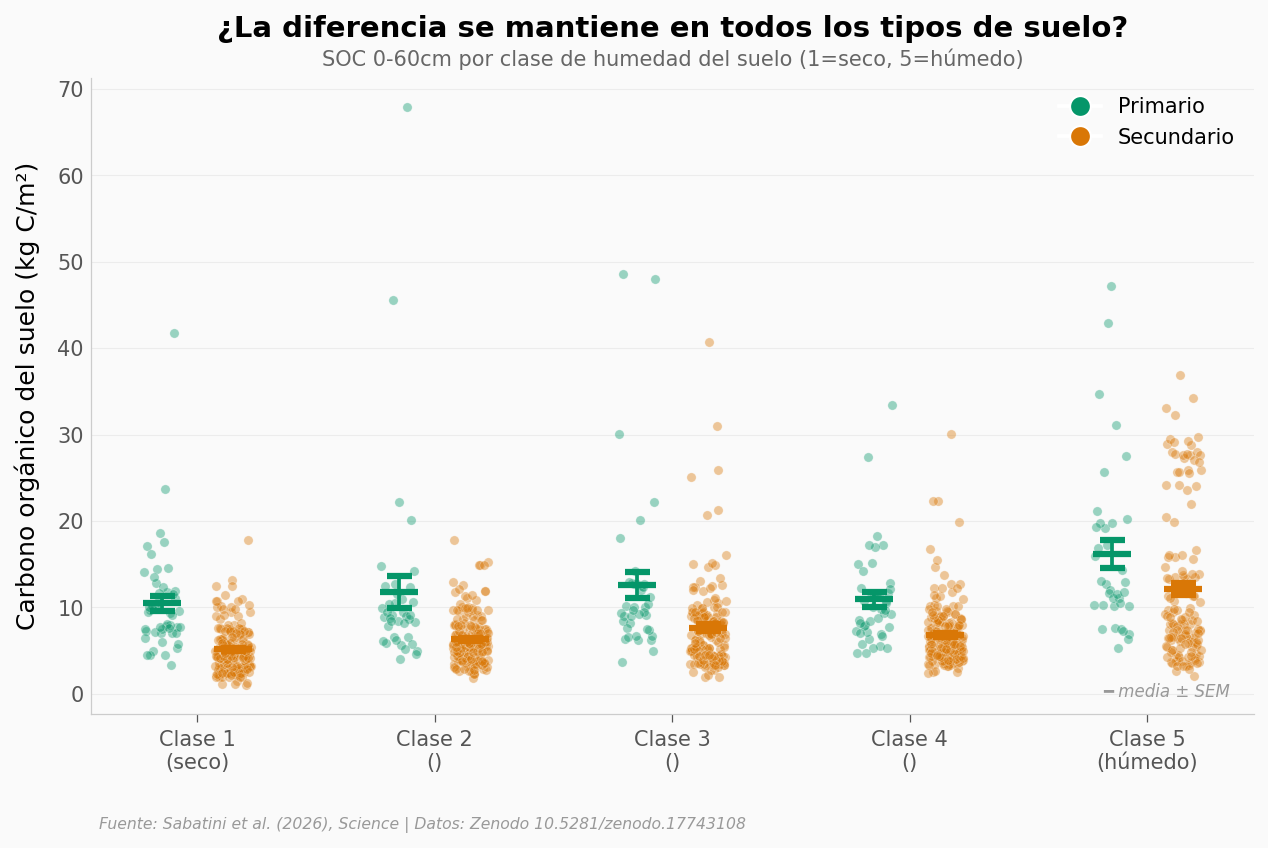

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))

np.random.seed(42)
classes = sorted(df_soc.humedad_suelo.unique())
positions_prim = np.arange(len(classes)) * 2
positions_sec = positions_prim + 0.6

for i, cls in enumerate(classes):
    for es_prim, pos, color, offset in [(1, positions_prim[i], COLOR_PRIMARIO, 0),
                                         (0, positions_sec[i], COLOR_SECUNDARIO, 0)]:
        vals = df_soc[(df_soc.humedad_suelo == cls) & (df_soc.es_primario == es_prim)]['soc_60cm_kgCm2'].dropna().values
        if len(vals) == 0:
            continue
        n = len(vals)
        x_strip = np.linspace(pos - 0.15, pos + 0.15, n)
        np.random.shuffle(x_strip)
        ax.scatter(x_strip, vals, color=color, s=20, alpha=0.4,
                   edgecolors='white', linewidths=0.3, zorder=5)
        mean = vals.mean()
        sem = vals.std(ddof=1) / np.sqrt(n)
        ax.errorbar(pos, mean, yerr=sem, fmt='_', color=color,
                    markersize=18, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)

# X-axis labels
mid_positions = (positions_prim + positions_sec) / 2
labels_cls = [f'Clase {int(c)}\n({"seco" if c==1 else "húmedo" if c==5 else ""})' for c in classes]
ax.set_xticks(mid_positions)
ax.set_xticklabels(labels_cls, fontsize=10)

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_PRIMARIO, markersize=10, label='Primario'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_SECUNDARIO, markersize=10, label='Secundario')]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right', framealpha=0.9)

ax.set_ylabel('Carbono orgánico del suelo (kg C/m²)')
ax.set_title('¿La diferencia se mantiene en todos los tipos de suelo?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'SOC 0-60cm por clase de humedad del suelo (1=seco, 5=húmedo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/soc_por_humedad.png', dpi=200, bbox_inches='tight')
plt.show()

En **todas** las clases de humedad, el bosque primario tiene más carbono en el suelo. La diferencia relativa es mayor en suelos secos (clase 1: +104%, clase 2: +88%) que en húmedos (clase 5: +33%), posiblemente porque los suelos húmedos retienen más carbono orgánico incluso bajo manejo.

## ¿Qué tan grande es la diferencia por componente?

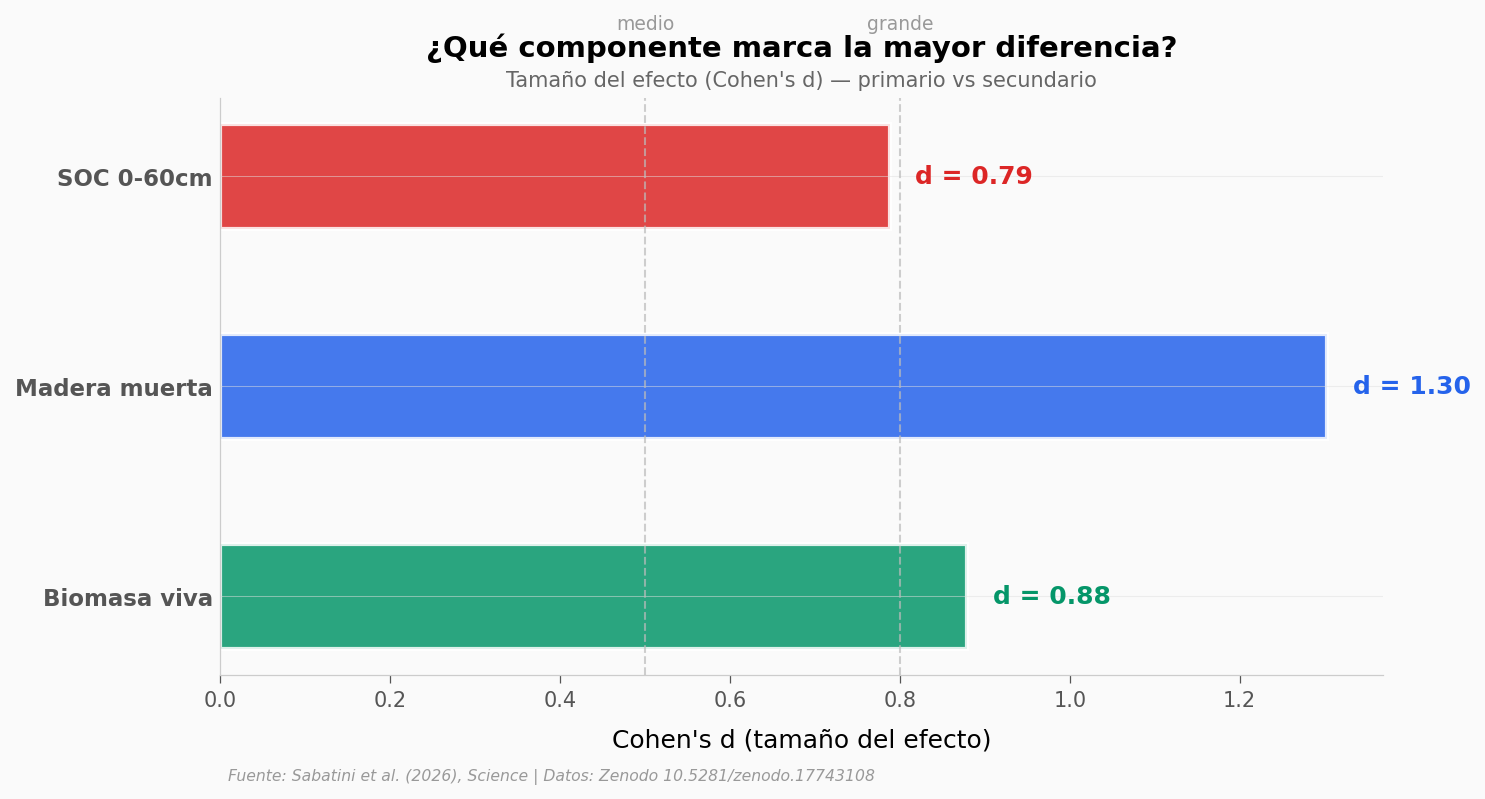

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Cohen's d for each component
components = ['Biomasa viva', 'Madera muerta', 'SOC 0-60cm']
d_values = []

# Live biomass
prim = df_veg[df_veg.es_primario == 1]['biomasa_viva_kgCm2']
sec = df_veg[df_veg.es_primario == 0]['biomasa_viva_kgCm2']
pooled = np.sqrt(((len(prim)-1)*prim.std(ddof=1)**2 + (len(sec)-1)*sec.std(ddof=1)**2) / (len(prim)+len(sec)-2))
d_values.append(abs(prim.mean() - sec.mean()) / pooled)

# Dead wood
prim_d = df_veg[df_veg.es_primario == 1]['madera_muerta_kgCm2']
sec_d = df_veg[df_veg.es_primario == 0]['madera_muerta_kgCm2']
pooled_d = np.sqrt(((len(prim_d)-1)*prim_d.std(ddof=1)**2 + (len(sec_d)-1)*sec_d.std(ddof=1)**2) / (len(prim_d)+len(sec_d)-2))
d_values.append(abs(prim_d.mean() - sec_d.mean()) / pooled_d)

# SOC
prim_s = df_soc[df_soc.es_primario == 1]['soc_60cm_kgCm2'].dropna()
sec_s = df_soc[df_soc.es_primario == 0]['soc_60cm_kgCm2'].dropna()
pooled_s = np.sqrt(((len(prim_s)-1)*prim_s.std(ddof=1)**2 + (len(sec_s)-1)*sec_s.std(ddof=1)**2) / (len(prim_s)+len(sec_s)-2))
d_values.append(abs(prim_s.mean() - sec_s.mean()) / pooled_s)

colors = [COLOR_PRIMARIO, COLOR_DATOS, COLOR_ALERTA]
bars = ax.barh(range(len(components)), d_values, color=colors, edgecolor='white',
               linewidth=2, alpha=0.85, height=0.5)

# Reference lines
ax.axvline(x=0.5, color='#BBBBBB', linewidth=1, linestyle='--', alpha=0.7)
ax.axvline(x=0.8, color='#BBBBBB', linewidth=1, linestyle='--', alpha=0.7)
ax.text(0.5, 2.7, 'medio', fontsize=9, color='#999999', ha='center')
ax.text(0.8, 2.7, 'grande', fontsize=9, color='#999999', ha='center')

# Values on bars
for i, d in enumerate(d_values):
    ax.text(d + 0.03, i, f'd = {d:.2f}', fontsize=12, fontweight='bold',
            color=colors[i], va='center')

ax.set_yticks(range(len(components)))
ax.set_yticklabels(components, fontsize=11, fontweight='bold')
ax.set_xlabel("Cohen's d (tamaño del efecto)")
ax.set_title('¿Qué componente marca la mayor diferencia?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Tamaño del efecto (Cohen\'s d) — primario vs secundario',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cohens_d_componentes.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Bosques primarios almacenan ~72% más carbono total | ✅ | Nuestro cálculo: +75% (medias directas). Paper: 70-74% según método. n = 324 + 28,580 (veg), 212 + 903 (suelo) |
| La biomasa viva es mayor en primarios | ✅ | 7.52 vs 4.21 kg C/m², d = 0.88 (grande), Mann-Whitney p < 0.001 |
| La madera muerta es mucho mayor en primarios | ✅ | 1.31 vs 0.41 kg C/m² (+223%), d = 1.30 (muy grande), Mann-Whitney p < 0.001 |
| El suelo es el mayor almacén y la mayor diferencia | ✅ | 12.23 vs 7.40 kg C/m² (+65%), d = 0.79 (grande), Mann-Whitney p < 0.001 |
| La diferencia es 2.7-8.0x mayor que estimaciones previas | ⚠️ | No tenemos las estimaciones previas en estos datos — es una claim comparativa del paper |

> **Limitaciones:**
> - Las parcelas primarias (n = 324) son ~100x menos que las secundarias (n = 28,580). El paper usa análisis pareado por humedad del suelo para controlar esto.
> - Los datos de suelo se miden a 60 cm de profundidad — el carbono más profundo no está incluido.
> - Las coordenadas de parcelas NFI son confidenciales (ley de privacidad sueca), así que no podemos verificar la distribución geográfica.
> - Los bosques primarios de Suecia son boreales — la diferencia podría ser distinta en bosques templados o tropicales.

## Ahora tú

Tres preguntas para explorar:

1. **¿La edad del bosque importa?** Los datos de vegetación incluyen parcelas pareadas por `forest_id`. ¿Las parcelas primarias más viejas almacenan más carbono, o hay un techo? (Pista: agrupa por `forest_id` y compara)

2. **¿Cuál es la distribución de la madera muerta?** La madera muerta tiene la mayor diferencia relativa (+220%). ¿Hay muchas parcelas secundarias con 0 madera muerta? (Pista: `df_veg[df_veg.es_primario == 0]['madera_muerta_kgCm2'].describe()`)

3. **¿Cuánto carbono se "libera" al manejar un bosque?** Si una hectárea de bosque primario pasa a secundario, ¿cuántas toneladas de CO₂ equivalente se pierden? (Pista: 1 kg C/m² = 10 ton C/ha, factor CO₂ = 3.67)

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuántas toneladas de CO₂ se pierden al manejar una hectárea de bosque primario?

prim_total = (df_veg[df_veg.es_primario == 1]['biomasa_viva_kgCm2'].mean() +
              df_veg[df_veg.es_primario == 1]['madera_muerta_kgCm2'].mean() +
              df_soc[df_soc.es_primario == 1]['soc_60cm_kgCm2'].mean())
sec_total = (df_veg[df_veg.es_primario == 0]['biomasa_viva_kgCm2'].mean() +
             df_veg[df_veg.es_primario == 0]['madera_muerta_kgCm2'].mean() +
             df_soc[df_soc.es_primario == 0]['soc_60cm_kgCm2'].mean())

diff_kgC_m2 = prim_total - sec_total
diff_tonC_ha = diff_kgC_m2 * 10  # 1 kg/m² = 10 ton/ha
diff_tonCO2_ha = diff_tonC_ha * 3.67  # Factor C → CO₂

print(f"Carbono primario: {prim_total:.1f} kg C/m²")
print(f"Carbono secundario: {sec_total:.1f} kg C/m²")
print(f"Diferencia: {diff_kgC_m2:.1f} kg C/m²")
print(f"\nPor hectárea:")
print(f"  {diff_tonC_ha:.0f} toneladas de carbono")
print(f"  {diff_tonCO2_ha:.0f} toneladas de CO₂ equivalente")
print(f"\n→ La diferencia entre 1 hectárea de bosque primario vs secundario equivale a ~{diff_tonCO2_ha:.0f} ton CO₂")

Carbono primario: 21.1 kg C/m²
Carbono secundario: 12.0 kg C/m²
Diferencia: 9.0 kg C/m²

Por hectárea:
  90 toneladas de carbono
  332 toneladas de CO₂ equivalente

→ La diferencia entre 1 hectárea de bosque primario vs secundario equivale a ~332 ton CO₂


---

## Créditos

- **Paper:** Sabatini, Anderegg, Angelstam et al. (2026). *Primary boreal forests store substantially more carbon than managed secondary forests.* Science.
- **DOI:** [10.1126/science.adz8554](https://doi.org/10.1126/science.adz8554)
- **Datos:** [Zenodo](https://doi.org/10.5281/zenodo.17743108) — análisis pareado e inventarios de campo
- **Licencia datos:** Creative Commons Attribution 4.0
- **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)